In [1]:
from MeravErez.filenames import *
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(font_scale=2.2,style='white')
import pandas as pd
import numpy as np
import scipy
import pickle as pkl

# Load

In [2]:
hr = pkl.load(open(hr_agg_filename_grace_cont_14d, 'rb'))

In [3]:
hrv = pkl.load(open(hrv_agg_filename_grace_cont_14d, 'rb'))

In [4]:
df_pinfo = pd.read_csv(pinfo_filename)
df_pinfo['participant_num'] = df_pinfo['participant_num'].astype(str)
print(len(df_pinfo))
df_pinfo.head()

2579


,participant_num,gender,age,weight,height,days_sick_30,heart_disease,blood_pressure,diabetes,lungs,cancer,renal_failure,immunosuppression,other,healthy
0,1,Female,74.0,66.0,159.0,0.0,True,False,False,False,False,False,False,False,False
1,10,Male,53.0,74.0,79.0,0.0,False,False,False,False,False,False,False,False,True
2,100,Male,64.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1000,Male,49.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,101,Male,59.0,105.0,181.0,0.0,False,True,False,False,False,False,False,False,False


In [5]:
latest_filename = '/home/data/permed/unified/dataframe/20210923/df_q_unified_pilot12_20210923.csv'
df = pd.read_csv(latest_filename, low_memory=False)

# Plot sample HR after the 3rd vaccine

In [6]:
sample_parts = df_pinfo['participant_num'].values[0:60]

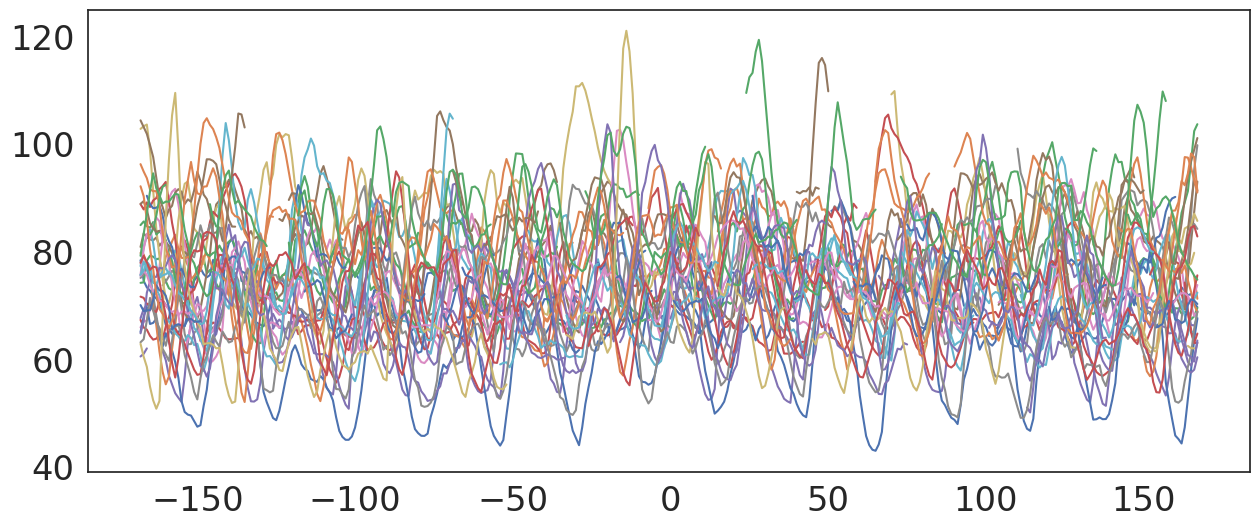

In [7]:
fig = plt.figure(figsize=(15,6), facecolor='white')

for part in sample_parts:
    if part in hr['third'].keys():
        plt.plot(np.arange(-168, 168), hr['third'][part]["hourly_smoothed"][24*7:24*21])
plt.show()

# Functions

In [8]:
# generate a wraparound array of the day of the week, such as
# [2, 3, 4, 5, 6, 0, 1]
# and then repeat each value 24 times in a row
# tile the remaining array twice
def generate_day_of_week_array(starting_date):
    arr = np.arange(starting_date, starting_date + 7)
    arr = np.where(arr >=7, arr-7, arr)
    return np.tile(np.repeat(arr, 24), 2)

# generate a wraparound array of the hour of day,
# from 0 to 23 repeating
def generate_hour_of_day_array(starting_hour):
    arr = np.arange(starting_hour, starting_hour + 24)
    arr = np.where(arr >=24, arr-24, arr)
    return np.tile(arr, 14)

day_of_week_arrs = dict()
hour_of_day_arrs = dict()

for i in range(7):
    day_of_week_arrs[i] = generate_day_of_week_array(i)
    
for i in range(24):
    hour_of_day_arrs[i] = generate_hour_of_day_array(i)

In [9]:
participant_num_to_hr_data_3 = dict()
for part in hr['third'].keys():
    participant_num_to_hr_data_3[part] = hr['third'][part]["hourly_imputed"][24*7:24*21]
    
participant_num_to_hrv_data_3 = dict()
for part in hrv['third'].keys():
    participant_num_to_hrv_data_3[part] = hrv['third'][part]["hourly_imputed"][24*7:24*21]
    
participant_num_to_hr_data_2 = dict()
for part in hr['second'].keys():
    participant_num_to_hr_data_2[part] = hr['second'][part]["hourly_imputed"][24*7:24*21]
    
participant_num_to_hrv_data_2 = dict()
for part in hrv['second'].keys():
    participant_num_to_hrv_data_2[part] = hrv['second'][part]["hourly_imputed"][24*7:24*21]

# Create datasets for panel regression after the 3rd vaccine

In [10]:

with open('v1_participant_nums.pkl', 'rb') as f:
    v1_participant_nums = pkl.load(f)
    
with open('v2_participant_nums.pkl', 'rb') as f:
    v2_participant_nums = pkl.load(f)
    
with open('v3_participant_nums.pkl', 'rb') as f:
    v3_participant_nums = pkl.load(f)

In [11]:
new_df = df.copy()

new_df = new_df[['participant_num', 'gender', 'age', 'healthy', 'third_dose_date']]
new_df = new_df.dropna(how='any')
new_df = new_df.drop_duplicates()
new_df['third_dose_date'] = pd.to_datetime(new_df['third_dose_date'])

In [12]:
new_df['vaccine_day'] = new_df['third_dose_date'].dt.dayofweek
new_df['vaccine_hour'] = new_df['third_dose_date'].dt.hour

new_df['vaccine_day'] = new_df['vaccine_day'].map(day_of_week_arrs)
new_df['vaccine_hour'] = new_df['vaccine_hour'].map(hour_of_day_arrs)

new_df['time'] = [np.arange(-168, 168)] * len(new_df)

In [13]:
df_hr = new_df.copy()
df_hrv = new_df.copy()

df_hr['hr'] = df_hr['participant_num'].map(participant_num_to_hr_data_3)
df_hrv['hrv'] = df_hrv['participant_num'].map(participant_num_to_hrv_data_3)

In [15]:
p_to_missing_vals = dict()
missing_all_vals = list()

for p, hr in participant_num_to_hr_data_3.items():
    p_to_missing_vals[p] = np.count_nonzero(np.isnan(hr))
    if p_to_missing_vals[p] == 336:
        missing_all_vals.append(p)
print("%d participants have entirely null arrays when looking at HR" % (len(missing_all_vals)))

51 participants have entirely null arrays when looking at HR


In [16]:
df_hr = df_hr.dropna(how='any')
df_hrv = df_hrv.dropna(how='any')

In [17]:
df_hr_final = df_hr.set_index(['participant_num', 'gender',
                               'age', 'healthy', 'third_dose_date']).apply(pd.Series.explode).reset_index()

df_hrv_final = df_hrv.set_index(['participant_num', 'gender',
                               'age', 'healthy', 'third_dose_date']).apply(pd.Series.explode).reset_index()

In [18]:
df_hr_final.to_csv('panel_regr_data_hr_3.csv')
df_hrv_final.to_csv('panel_regr_data_hrv_3.csv')

In [19]:
df_hr_final.head()

,participant_num,gender,age,healthy,third_dose_date,vaccine_day,vaccine_hour,time,hr
0,1,Female,74.0,False,2021-08-09 15:15:00,0,15,-168,72.283333
1,1,Female,74.0,False,2021-08-09 15:15:00,0,16,-167,68.966667
2,1,Female,74.0,False,2021-08-09 15:15:00,0,17,-166,73.983333
3,1,Female,74.0,False,2021-08-09 15:15:00,0,18,-165,72.833333
4,1,Female,74.0,False,2021-08-09 15:15:00,0,19,-164,71.233333


In [20]:
df_hrv_final.head()

,participant_num,gender,age,healthy,third_dose_date,vaccine_day,vaccine_hour,time,hrv
0,1,Female,74.0,False,2021-08-09 15:15:00,0,15,-168,11.0
1,1,Female,74.0,False,2021-08-09 15:15:00,0,16,-167,8.9375
2,1,Female,74.0,False,2021-08-09 15:15:00,0,17,-166,15.8
3,1,Female,74.0,False,2021-08-09 15:15:00,0,18,-165,15.0
4,1,Female,74.0,False,2021-08-09 15:15:00,0,19,-164,9.181818


# Create datasets for panel regression after the 2nd vaccine

In [21]:
new_df = df.copy()

new_df = new_df[['participant_num', 'gender', 'age', 'healthy', 'second_dose_date']]
new_df = new_df.dropna(how='any')
new_df = new_df.drop_duplicates()
new_df['second_dose_date'] = pd.to_datetime(new_df['second_dose_date'])

In [22]:
new_df['vaccine_day'] = new_df['second_dose_date'].dt.dayofweek
new_df['vaccine_hour'] = new_df['second_dose_date'].dt.hour

new_df['vaccine_day'] = new_df['vaccine_day'].map(day_of_week_arrs)
new_df['vaccine_hour'] = new_df['vaccine_hour'].map(hour_of_day_arrs)

new_df['time'] = [np.arange(-168, 168)] * len(new_df)

In [23]:
df_hr = new_df.copy()
df_hrv = new_df.copy()

df_hr['hr'] = df_hr['participant_num'].map(participant_num_to_hr_data_2)
df_hrv['hrv'] = df_hrv['participant_num'].map(participant_num_to_hrv_data_2)

In [24]:
df_hr = df_hr.dropna(how='any')
df_hrv = df_hrv.dropna(how='any')

In [25]:
df_hr_final = df_hr.set_index(['participant_num', 'gender',
                               'age', 'healthy', 'second_dose_date']).apply(pd.Series.explode).reset_index()

df_hrv_final = df_hrv.set_index(['participant_num', 'gender',
                               'age', 'healthy', 'second_dose_date']).apply(pd.Series.explode).reset_index()

In [26]:
df_hr_final.to_csv('panel_regr_data_hr_2.csv')
df_hrv_final.to_csv('panel_regr_data_hrv_2.csv')